In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("restaurants.csv")

In [6]:
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue,COGSRate,OPEXRate,CommissionRate,DeliveryRadiusKM,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,212,118,141,9321.64,5188.46,6199.77,0.208741,0.366172,0.28,11,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,508,282,339,20548.60,11406.90,13712.55,0.248217,0.407613,0.28,16,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,537,298,358,21496.11,11928.94,14330.74,0.219688,0.407932,0.30,11,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,390,217,260,14149.20,7872.76,9432.80,0.237291,0.437815,0.33,3,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,436,242,291,14972.24,8310.28,9992.94,0.221438,0.433457,0.33,9,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [7]:
df.shape

(1696, 30)

In [8]:
df.shape

(1696, 30)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   str    
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   str    
 3   Segment                1696 non-null   str    
 4   Subregion              1696 non-null   str    
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  SelfDeliveryRev

In [10]:
df.describe()

,RestaurantID,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue,COGSRate,OPEXRate,CommissionRate,DeliveryRadiusKM,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,25848.500000,1.028255,38.516887,1190.527123,218.980542,8422.392730,471.906250,257.155071,242.485259,18170.030360,9899.399145,9345.033190,0.280149,0.411650,0.300277,10.565448,3.119363,755.783886,2257.321557,152.410425,89.105100,2139.315118,0.225654,0.486763,0.265242,0.247995
std,489.737345,0.022700,4.459408,422.334848,149.758619,5851.233352,171.781981,92.605301,129.950736,6959.241673,3750.087557,5191.322908,0.061760,0.073420,0.017931,4.559197,1.344848,541.323056,1618.692119,2340.125579,1271.832584,1875.802610,0.126977,0.067685,0.034294,0.094582
min,25001.000000,0.990000,29.790000,441.000000,13.000000,412.360000,142.000000,81.000000,60.000000,5050.950000,2876.700000,1897.200000,0.200369,0.200301,0.270000,3.000000,0.890000,53.400000,155.000000,-7787.110000,-4349.940000,-983.280000,0.030000,0.350000,0.200000,0.150000
25%,25424.750000,1.030000,34.787500,827.000000,101.000000,3904.342500,331.000000,179.750000,146.000000,12524.745000,6806.920000,5631.852500,0.232270,0.372182,0.280000,6.000000,1.770000,358.662500,1122.580000,-1291.512500,-718.617500,807.867500,0.110000,0.450000,0.250000,0.150000
50%,25848.500000,1.040000,38.340000,1182.000000,178.000000,6791.430000,456.000000,249.000000,212.000000,17548.980000,9564.800000,8066.460000,0.261271,0.411785,0.300000,11.000000,3.250000,601.800000,1785.720000,676.685000,369.665000,1742.945000,0.210000,0.500000,0.250000,0.200000
75%,26272.250000,1.050000,42.495000,1525.000000,307.000000,11550.755000,602.000000,326.250000,306.250000,23016.000000,12617.602500,11852.907500,0.352189,0.456814,0.320000,14.000000,4.130000,1005.030000,2848.090000,1581.570000,862.602500,2995.282500,0.320000,0.550000,0.300000,0.300000
max,26696.000000,1.050000,47.230000,2337.000000,819.000000,35356.230000,937.000000,466.000000,702.000000,43038.960000,21313.440000,32481.540000,0.399826,0.549688,0.330000,18.000000,5.310000,3653.280000,10474.680000,8275.570000,4514.880000,13222.100000,0.550000,0.600000,0.300000,0.450000


In [11]:
df.isnull().sum()

CuisineType              0
RestaurantID             0
RestaurantName           0
Segment                  0
Subregion                0
GrowthFactor             0
AOV                      0
MonthlyOrders            0
InStoreOrders            0
InStoreRevenue           0
UberEatsOrders           0
DoorDashOrders           0
SelfDeliveryOrders       0
UberEatsRevenue          0
DoorDashRevenue          0
SelfDeliveryRevenue      0
COGSRate                 0
OPEXRate                 0
CommissionRate           0
DeliveryRadiusKM         0
DeliveryCostPerOrder     0
SD_DeliveryTotalCost     0
InStoreNetProfit         0
UberEatsNetProfit        0
DoorDashNetProfit        0
SelfDeliveryNetProfit    0
InStoreShare             0
UE_share                 0
DD_share                 0
SD_share                 0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["CalculatedOrders"] = (
    df["InStoreOrders"]
    + df["UberEatsOrders"]
    + df["DoorDashOrders"]
    + df["SelfDeliveryOrders"]
)

df["MonthlyOrders"] - df["CalculatedOrders"]

0       0
1       0
2       0
3       0
4       0
       ..
1691    0
1692    0
1693    0
1694    0
1695    0
Length: 1696, dtype: int64

In [14]:
(df["MonthlyOrders"] == df["CalculatedOrders"]).value_counts()

True    1696
Name: count, dtype: int64

In [15]:
df["TotalShare"] = (
    df["InStoreShare"]
    + df["UE_share"]
    + df["DD_share"]
    + df["SD_share"]
)

df["TotalShare"].head()

0    1.42
1    1.23
2    1.44
3    1.25
4    1.27
Name: TotalShare, dtype: float64

In [16]:
channel_orders = {
    "In-Store": df["InStoreOrders"].sum(),
    "Uber Eats": df["UberEatsOrders"].sum(),
    "DoorDash": df["DoorDashOrders"].sum(),
    "Self Delivery": df["SelfDeliveryOrders"].sum()
}

channel_orders

{'In-Store': np.int64(371391),
 'Uber Eats': np.int64(800353),
 'DoorDash': np.int64(436135),
 'Self Delivery': np.int64(411255)}

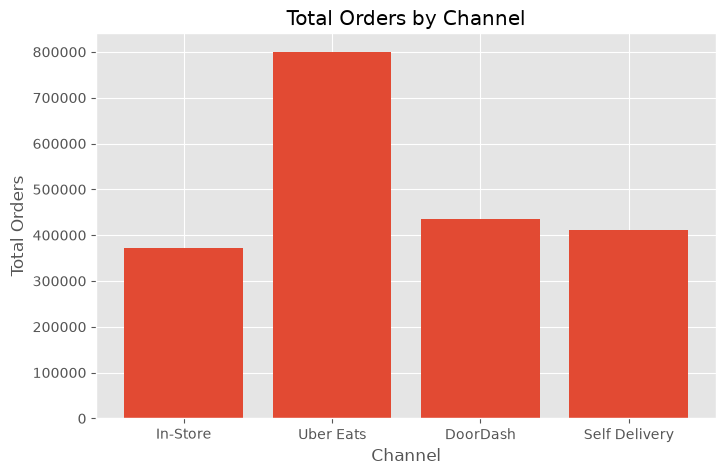

In [17]:
plt.figure(figsize=(8,5))

plt.bar(channel_orders.keys(), channel_orders.values())

plt.title("Total Orders by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Orders")

plt.show()

In [18]:
total_orders = sum(channel_orders.values())

market_share = {}

for channel, orders in channel_orders.items():
    market_share[channel] = round((orders / total_orders) * 100,2)

market_share

{'In-Store': np.float64(18.39),
 'Uber Eats': np.float64(39.64),
 'DoorDash': np.float64(21.6),
 'Self Delivery': np.float64(20.37)}

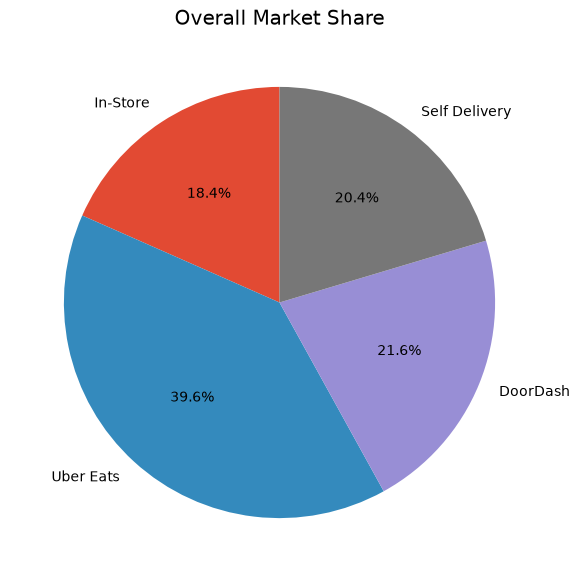

In [19]:
plt.figure(figsize=(7,7))

plt.pie(
    market_share.values(),
    labels=market_share.keys(),
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Overall Market Share")

plt.show()

In [20]:
delivery_orders = (
    df["UberEatsOrders"].sum() +
    df["DoorDashOrders"].sum() +
    df["SelfDeliveryOrders"].sum()
)

instore_orders = df["InStoreOrders"].sum()

comparison = pd.DataFrame({
    "Type":["In-Store","Delivery"],
    "Orders":[instore_orders,delivery_orders]
})

comparison

,Type,Orders
0,In-Store,371391
1,Delivery,1647743


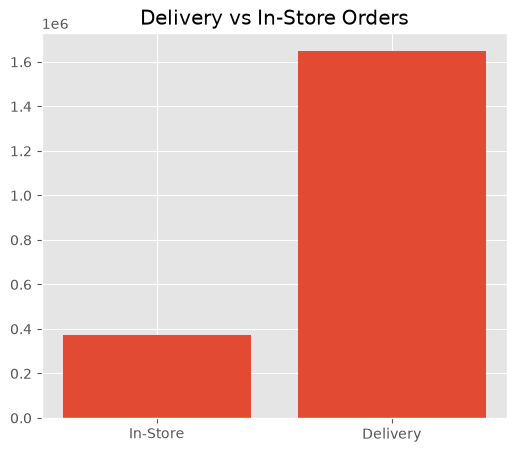

In [21]:
plt.figure(figsize=(6,5))

plt.bar(comparison["Type"],comparison["Orders"])

plt.title("Delivery vs In-Store Orders")

plt.show()

In [22]:
ranking = pd.DataFrame({
    "Channel":channel_orders.keys(),
    "Orders":channel_orders.values()
})

ranking.sort_values("Orders",ascending=False)

,Channel,Orders
1,Uber Eats,800353
2,DoorDash,436135
3,Self Delivery,411255
0,In-Store,371391


In [23]:
kpi = pd.DataFrame({
    "KPI":[
        "Total Orders",
        "Highest Channel",
        "Lowest Channel"
    ],
    "Value":[
        total_orders,
        ranking.sort_values("Orders",ascending=False).iloc[0]["Channel"],
        ranking.sort_values("Orders").iloc[0]["Channel"]
    ]
})

kpi

,KPI,Value
0,Total Orders,2019134
1,Highest Channel,Uber Eats
2,Lowest Channel,In-Store


In [24]:
subregion_orders = df.groupby("Subregion")[[
    "InStoreOrders",
    "UberEatsOrders",
    "DoorDashOrders",
    "SelfDeliveryOrders"
]].sum()

subregion_orders

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
Subregion,,,,
CBD,86929,187736,103376,95935
North Shore,86860,183977,99347,93222
South Auckland,95206,209895,113967,110181
West Auckland,102396,218745,119445,111917


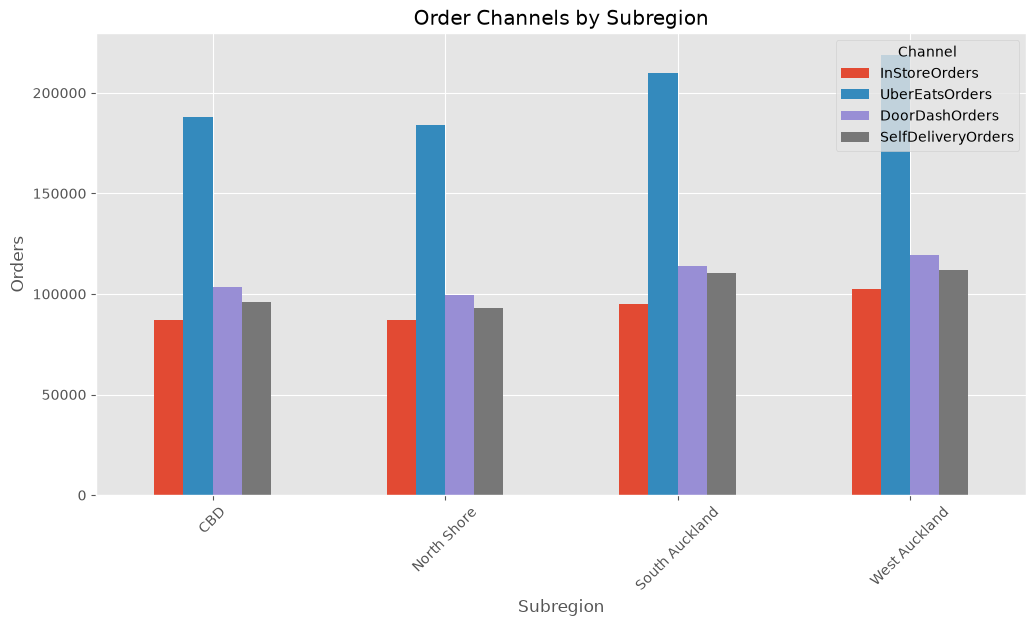

In [25]:
subregion_orders.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Order Channels by Subregion")
plt.xlabel("Subregion")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.legend(title="Channel")

plt.show()

In [26]:
subregion_share = subregion_orders.div(
    subregion_orders.sum(axis=1),
    axis=0
) * 100

subregion_share.round(2)

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
Subregion,,,,
CBD,18.34,39.61,21.81,20.24
North Shore,18.74,39.70,21.44,20.12
South Auckland,17.99,39.66,21.53,20.82
West Auckland,18.53,39.59,21.62,20.26


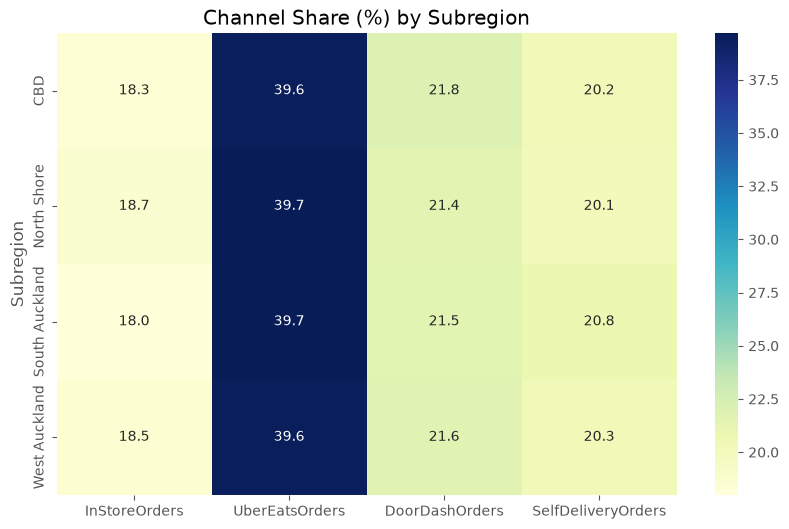

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    subregion_share,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Channel Share (%) by Subregion")

plt.show()

In [28]:
dominant_channel = subregion_share.idxmax(axis=1)

dominant_channel

Subregion
CBD               UberEatsOrders
North Shore       UberEatsOrders
South Auckland    UberEatsOrders
West Auckland     UberEatsOrders
dtype: str

In [29]:
dominant_df = pd.DataFrame({
    "Subregion": dominant_channel.index,
    "Dominant Channel": dominant_channel.values
})

dominant_df

,Subregion,Dominant Channel
0,CBD,UberEatsOrders
1,North Shore,UberEatsOrders
2,South Auckland,UberEatsOrders
3,West Auckland,UberEatsOrders


In [30]:
df.groupby("Subregion")["MonthlyOrders"] \
    .sum() \
    .sort_values(ascending=False)

Subregion
West Auckland     552503
South Auckland    529249
CBD               473976
North Shore       463406
Name: MonthlyOrders, dtype: int64

In [31]:
top_subregion = df.groupby("Subregion")["MonthlyOrders"].sum().idxmax()

print("Top Performing Subregion:", top_subregion)

Top Performing Subregion: West Auckland


In [32]:
cuisine_orders = df.groupby("CuisineType")[[
    "InStoreOrders",
    "UberEatsOrders",
    "DoorDashOrders",
    "SelfDeliveryOrders"
]].sum()

cuisine_orders

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
CuisineType,,,,
Burgers,113297,167213,92894,111471
Chicken Dishes,43091,83925,34972,20985
Chinese,45838,107778,53895,53895
Indian,44321,154862,92910,61958
Japanese,17196,64729,35302,17648
Kebabs/Mediterranean,23109,87329,47629,23823
Pizza,68145,76405,43663,98232
Thai,16394,58112,34870,23243


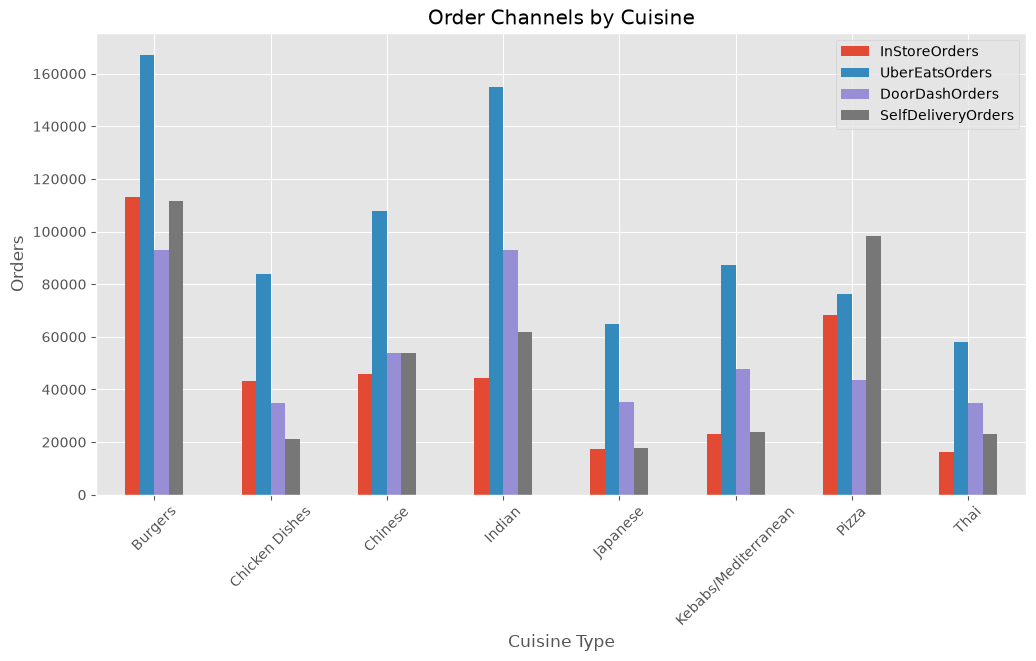

In [33]:
cuisine_orders.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Order Channels by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.show()

In [34]:
cuisine_share = cuisine_orders.div(
    cuisine_orders.sum(axis=1),
    axis=0
) * 100

cuisine_share.round(2)

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
CuisineType,,,,
Burgers,23.37,34.49,19.16,22.99
Chicken Dishes,23.55,45.87,19.11,11.47
Chinese,17.54,41.23,20.62,20.62
Indian,12.52,43.74,26.24,17.50
Japanese,12.75,47.99,26.17,13.08
Kebabs/Mediterranean,12.70,48.01,26.19,13.10
Pizza,23.79,26.67,15.24,34.29
Thai,12.36,43.82,26.29,17.53


In [35]:
dominant_cuisine = cuisine_share.idxmax(axis=1)

dominant_cuisine

CuisineType
Burgers                     UberEatsOrders
Chicken Dishes              UberEatsOrders
Chinese                     UberEatsOrders
Indian                      UberEatsOrders
Japanese                    UberEatsOrders
Kebabs/Mediterranean        UberEatsOrders
Pizza                   SelfDeliveryOrders
Thai                        UberEatsOrders
dtype: str

In [36]:
df.groupby("CuisineType")["MonthlyOrders"]\
.sum()\
.sort_values(ascending=False)

CuisineType
Burgers                 484875
Indian                  354051
Pizza                   286445
Chinese                 261406
Chicken Dishes          182973
Kebabs/Mediterranean    181890
Japanese                134875
Thai                    132619
Name: MonthlyOrders, dtype: int64

In [37]:
segment_orders = df.groupby("Segment")[[
    "InStoreOrders",
    "UberEatsOrders",
    "DoorDashOrders",
    "SelfDeliveryOrders"
]].sum()

segment_orders

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
Segment,,,,
Cafe,112714,237970,129729,121312
Full-service,152531,214271,116083,110157
Ghost Kitchen,13013,94463,51844,49449
QSR,93133,253649,138479,130337


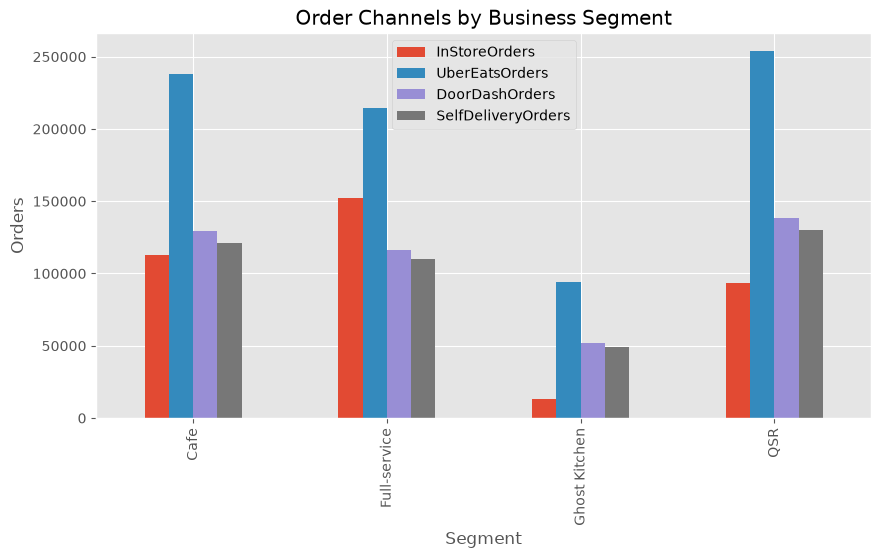

In [38]:
segment_orders.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Order Channels by Business Segment")

plt.xlabel("Segment")

plt.ylabel("Orders")

plt.show()

In [39]:
segment_share = segment_orders.div(
    segment_orders.sum(axis=1),
    axis=0
) * 100

segment_share.round(2)

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
Segment,,,,
Cafe,18.73,39.55,21.56,20.16
Full-service,25.72,36.13,19.57,18.57
Ghost Kitchen,6.23,45.25,24.83,23.69
QSR,15.13,41.20,22.50,21.17


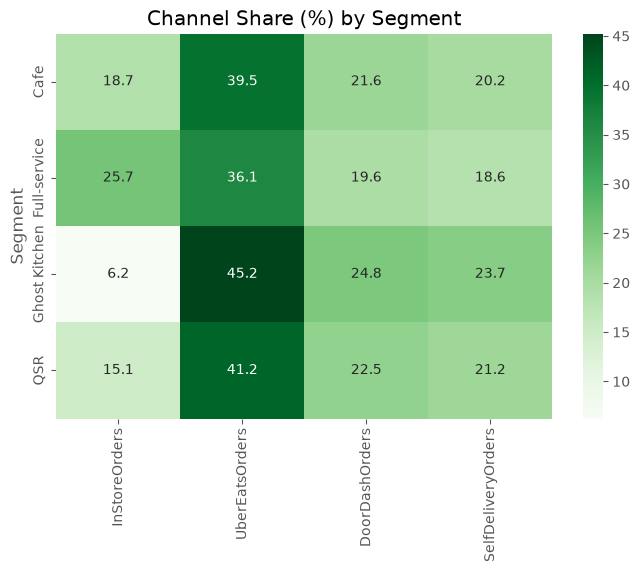

In [40]:
plt.figure(figsize=(8,5))

sns.heatmap(
    segment_share,
    annot=True,
    cmap="Greens",
    fmt=".1f"
)

plt.title("Channel Share (%) by Segment")

plt.show()

In [41]:
aggregator_share = (
    cuisine_share["UberEatsOrders"] +
    cuisine_share["DoorDashOrders"]
)

aggregator_share.sort_values(ascending=False)

CuisineType
Kebabs/Mediterranean    74.197592
Japanese                74.165709
Thai                    70.112126
Indian                  69.982008
Chicken Dishes          64.980626
Chinese                 61.847471
Burgers                 53.644135
Pizza                   41.916598
dtype: float64

In [42]:
high_dependency = aggregator_share[
    aggregator_share >= 70
]

high_dependency

CuisineType
Japanese                74.165709
Kebabs/Mediterranean    74.197592
Thai                    70.112126
dtype: float64

In [43]:
df["AggregatorDependence"] = (
    (
        df["UberEatsOrders"] +
        df["DoorDashOrders"]
    )
    / df["MonthlyOrders"]
) * 100

df[[
    "RestaurantName",
    "AggregatorDependence"
]].head()

,RestaurantName,AggregatorDependence
0,Urban Burgers House,49.401198
1,Urban Burgers Diner,56.916427
2,King Burgers Eatery,48.631334
3,Classic Burgers Tavern,56.048015
4,Lucky Burgers Bistro,55.121951


In [44]:
df["InStoreReliance"] = (
    df["InStoreOrders"]
    / df["MonthlyOrders"]
) * 100

df[[
    "RestaurantName",
    "InStoreReliance"
]].head()

,RestaurantName,InStoreReliance
0,Urban Burgers House,29.491018
1,Urban Burgers Diner,18.659942
2,King Burgers Eatery,30.518346
3,Classic Burgers Tavern,19.944598
4,Lucky Burgers Bistro,21.219512


In [45]:
df["SelfDeliveryReliance"] = (
    df["SelfDeliveryOrders"]
    / df["MonthlyOrders"]
) * 100

df[[
    "RestaurantName",
    "SelfDeliveryReliance"
]].head()

,RestaurantName,SelfDeliveryReliance
0,Urban Burgers House,21.107784
1,Urban Burgers Diner,24.423631
2,King Burgers Eatery,20.850320
3,Classic Burgers Tavern,24.007387
4,Lucky Burgers Bistro,23.658537


In [46]:
high_risk = df[
    df["AggregatorDependence"] >= 70
]

high_risk[[
    "RestaurantName",
    "AggregatorDependence"
]]

,RestaurantName,AggregatorDependence
382,Top Chicken Dishes Eatery,78.057890
383,Top Chicken Dishes Tavern,70.302548
392,King Chicken Dishes Tavern,77.990747
397,Lucky Chicken Dishes Diner,70.864382
408,Lucky Chicken Dishes Diner,80.995475
...,...,...
1689,Sakura Grill,70.828183
1691,Lotus Bistro,74.948665
1692,Dragon Bistro,74.790795
1693,Dragon Corner,73.482850


In [47]:
print("Total High Risk Restaurants :", len(high_risk))

Total High Risk Restaurants : 603


In [48]:
balanced = df[
    (df["AggregatorDependence"] < 50)
    &
    (df["InStoreReliance"] > 25)
    &
    (df["SelfDeliveryReliance"] > 10)
]

balanced[[
    "RestaurantName",
    "AggregatorDependence",
    "InStoreReliance",
    "SelfDeliveryReliance"
]]

,RestaurantName,AggregatorDependence,InStoreReliance,SelfDeliveryReliance
0,Urban Burgers House,49.401198,29.491018,21.107784
2,King Burgers Eatery,48.631334,30.518346,20.850320
16,Classic Burgers Tavern,46.378830,33.704735,19.916435
17,Classic Burgers Cafe,47.927840,31.496831,20.575329
26,Classic Burgers Tavern,48.644793,30.527817,20.827389
...,...,...,...,...
1569,King Pizza Diner,40.432612,26.455907,33.111481
1570,Classic Pizza Bistro,36.908078,32.869081,30.222841
1572,Lucky Pizza Tavern,38.214959,30.546826,31.238215
1574,Lucky Pizza Tavern,37.667699,31.475748,30.856553


In [49]:
df["DiversificationScore"] = (
    (df["InStoreShare"] > 0).astype(int)
    +
    (df["UE_share"] > 0).astype(int)
    +
    (df["DD_share"] > 0).astype(int)
    +
    (df["SD_share"] > 0).astype(int)
)

df[[
    "RestaurantName",
    "DiversificationScore"
]].head()

,RestaurantName,DiversificationScore
0,Urban Burgers House,4
1,Urban Burgers Diner,4
2,King Burgers Eatery,4
3,Classic Burgers Tavern,4
4,Lucky Burgers Bistro,4


In [50]:
df["DiversificationScore"].value_counts()

DiversificationScore
4    1696
Name: count, dtype: int64

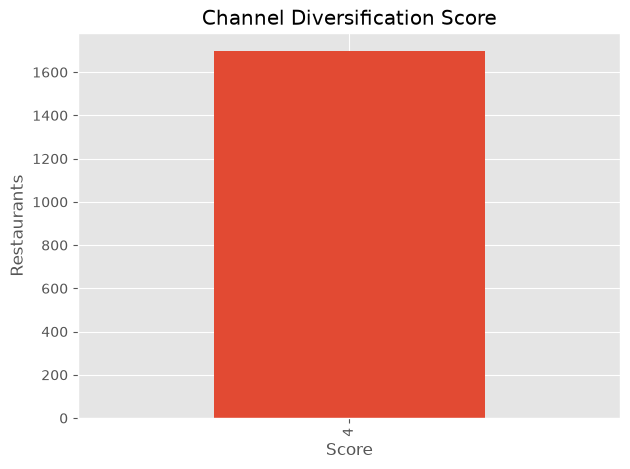

In [51]:
plt.figure(figsize=(7,5))

df["DiversificationScore"]\
.value_counts()\
.sort_index()\
.plot(kind="bar")

plt.title("Channel Diversification Score")

plt.xlabel("Score")

plt.ylabel("Restaurants")

plt.show()

In [52]:
kpi_dashboard = pd.DataFrame({

"KPI":[
"Total Restaurants",
"Total Monthly Orders",
"Average AOV",
"Average Aggregator Dependence (%)",
"Average InStore Reliance (%)",
"High Risk Restaurants",
"Balanced Restaurants"
],

"Value":[

len(df),

df["MonthlyOrders"].sum(),

round(df["AOV"].mean(),2),

round(df["AggregatorDependence"].mean(),2),

round(df["InStoreReliance"].mean(),2),

len(high_risk),

len(balanced)

]

})

kpi_dashboard

,KPI,Value
0,Total Restaurants,1696.00
1,Total Monthly Orders,2019134.00
2,Average AOV,38.52
3,Average Aggregator Dependence (%),62.34
4,Average InStore Reliance (%),17.52
5,High Risk Restaurants,603.00
6,Balanced Restaurants,181.00


In [53]:
df.sort_values(
    "AggregatorDependence",
    ascending=False
)[[
    "RestaurantName",
    "Subregion",
    "CuisineType",
    "AggregatorDependence"
]].head(10)

,RestaurantName,Subregion,CuisineType,AggregatorDependence
1322,Spice Bistro,South Auckland,Kebabs/Mediterranean,82.672234
426,Lucky Chicken Dishes Diner,South Auckland,Chicken Dishes,82.644628
1178,Golden Corner,West Auckland,Japanese,82.593250
486,Urban Chicken Dishes Diner,North Shore,Chicken Dishes,82.571429
1238,Souvlaki Corner,North Shore,Kebabs/Mediterranean,82.543103
459,Lucky Chicken Dishes Bistro,North Shore,Chicken Dishes,81.818182
1111,Golden Corner,North Shore,Japanese,81.748466
477,Classic Chicken Dishes Tavern,West Auckland,Chicken Dishes,81.736527
1128,Sakura House,South Auckland,Japanese,81.097561
1257,Ottoman Cafe,West Auckland,Kebabs/Mediterranean,81.061947


In [54]:
df.sort_values(
    "DiversificationScore",
    ascending=False
)[[
    "RestaurantName",
    "Subregion",
    "CuisineType",
    "DiversificationScore"
]].head(10)

,RestaurantName,Subregion,CuisineType,DiversificationScore
0,Urban Burgers House,North Shore,Burgers,4
1,Urban Burgers Diner,South Auckland,Burgers,4
2,King Burgers Eatery,West Auckland,Burgers,4
3,Classic Burgers Tavern,North Shore,Burgers,4
4,Lucky Burgers Bistro,South Auckland,Burgers,4
5,King Burgers Kitchen,North Shore,Burgers,4
6,Urban Burgers Eatery,South Auckland,Burgers,4
7,Urban Burgers Tavern,CBD,Burgers,4
8,Classic Burgers Tavern,CBD,Burgers,4
9,Lucky Burgers Cafe,South Auckland,Burgers,4
